#### Mount drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Add project folder to path
import sys
sys.path.append('/content/drive/MyDrive/dales-bp-mech-interp/')  # Update this path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from tqdm import tqdm

In [ ]:
from numpy.linalg import eig, svd
from sklearn.decomposition import PCA

In [ ]:
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR

In [ ]:
import os
import pickle
import json

In [ ]:
from data_loader import makeTensorLoaders

#### Test for CUDA

In [ ]:
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('No GPU, training on CPU')
    device = torch.device('cpu')
else:
    print('GPU found, training on GPU')
    device = torch.device('cuda')

GPU found, training on GPU


#### Simulation parameters

In [ ]:
N = 128 ## number of recurrent neurons
nsecs = 20 ## time
n_channels = 3

In [ ]:
nRuns = 3

#### Train and test datasets

In [ ]:
def random_assignment(numSamps, n, p):
    # Create a zero array of shape (numSamps, n)
    arr = np.random.choice([-1, 1], size=(numSamps, n))

    # Randomly assign 1 or -1 to elements with probability p
    rand_arr = np.random.random(arr.shape)
    arr[np.random.random(arr.shape) > p] = 0

    return arr

In [ ]:
def random_assignment_context(numSamps, n, p_event=0.2, p_ctx_switch=0.05):
    """Generate two-channel pulses + binary context channel.

    Returns: inputs of shape (numSamps, n, 3)
        inputs[...,0]: channel 1 pulses in {-1,0,+1}
        inputs[...,1]: channel 2 pulses in {-1,0,+1}
        inputs[...,2]: context c_t in {+1,-1} ( +1 => ch1 relevant, -1 => ch2 relevant )
    """
    x = np.zeros((numSamps, n, 3), dtype=float)
    # initialize context to +1
    ctx = np.ones((numSamps, n), dtype=float)

    # probabilistic context switches
    for b in range(numSamps):
        c = 1.0
        for t in range(n):
            if np.random.rand() < p_ctx_switch:
                c = -c
            ctx[b, t] = c

    # pulses on both channels with prob p_event/2 each
    # signs are +/-1 equiprobable
    ch1_mask = (np.random.rand(numSamps, n) < (p_event/2.0))
    ch2_mask = (np.random.rand(numSamps, n) < (p_event/2.0))
    ch1_sign = np.where(np.random.rand(numSamps, n) < 0.5, -1.0, 1.0)
    ch2_sign = np.where(np.random.rand(numSamps, n) < 0.5, -1.0, 1.0)

    x[...,0] = ch1_mask * ch1_sign
    x[...,1] = ch2_mask * ch2_sign
    x[...,2] = ctx
    return x

In [ ]:
def flipflop_output_context(input_array_3ch):
    """Compute flip-flop target under context gating.
    input_array_3ch: shape (n, 3) with [ch1, ch2, context(+1/-1)]
    Only pulses on the channel matching the context cause a flip.
    Output: shape (n,) in {-1,0,+1} (start at 0, then +/-1 after first command)
    """
    n = input_array_3ch.shape[0]
    out = np.zeros((n,), dtype=float)
    state = 0.0
    for t in range(n):
        ch1, ch2, c = input_array_3ch[t]
        # relevant channel is ch1 if c=+1 else ch2
        if c >= 0:  # ch1 relevant
            if ch1 != 0:
                state = np.sign(ch1) if ch1 != 0 else state
        else:       # ch2 relevant
            if ch2 != 0:
                state = np.sign(ch2) if ch2 != 0 else state
        out[t:] = state
    return out
    # Create a zero array of shape (numSamps, n)
    arr = np.random.choice([-1, 1], size=(numSamps, n))

    # Randomly assign 1 or -1 to elements with probability p
    rand_arr = np.random.random(arr.shape)
    arr[np.random.random(arr.shape) > p] = 0

    return arr

In [ ]:
nTrain = 2000
nTest = 1000
prob_delta = 0.2

In [ ]:
batch_size = 200

In [ ]:
def flipflop_output(input_array):
    output_array = np.zeros_like(input_array)
    current_state = 0  # Track the current state

    for tt in range(len(input_array)):
        if input_array[tt] !=0:
            current_state = input_array[tt]
            output_array[tt:] = current_state

    return output_array


data_in_train = {}
data_in_test = {}

data_out_train = {}
data_out_test = {}

for cntr in range(nRuns):
    if n_channels == 1:
        data_in_train[cntr] = random_assignment(nTrain, nsecs, prob_delta)
        data_in_test[cntr]  = random_assignment(nTest, nsecs, prob_delta)

        data_out_train[cntr] = np.zeros_like(data_in_train[cntr])
        data_out_test[cntr]  = np.zeros_like(data_in_test[cntr])

        for ii in range(nTrain):
            data_out_train[cntr][ii] = flipflop_output(data_in_train[cntr][ii])
        for ii in range(nTest):
            data_out_test[cntr][ii] = flipflop_output(data_in_test[cntr][ii])
    else:
        # Two-channel + context (3 inputs)
        data_in_train[cntr] = random_assignment_context(nTrain, nsecs, prob_delta, p_ctx_switch=0.05)
        data_in_test[cntr]  = random_assignment_context(nTest, nsecs, prob_delta, p_ctx_switch=0.05)

        # Targets are scalar sequence (no channel dim)
        data_out_train[cntr] = np.zeros((nTrain, nsecs), dtype=float)
        data_out_test[cntr]  = np.zeros((nTest,  nsecs), dtype=float)

        for ii in range(nTrain):
            data_out_train[cntr][ii] = flipflop_output_context(data_in_train[cntr][ii])
        for ii in range(nTest):
            data_out_test[cntr][ii] = flipflop_output_context(data_in_test[cntr][ii])

train_loader = {}
test_loader = {}

for cntr in range(nRuns):
    train_loader[cntr] = makeTensorLoaders((data_in_train[cntr], data_out_train[cntr]), batch_size, shuffle=True)
    test_loader[cntr]  = makeTensorLoaders((data_in_test[cntr],  data_out_test[cntr]),  batch_size, shuffle=False)
train_loader = {}
test_loader = {}

for cntr in range(nRuns):
    train_loader[cntr] = makeTensorLoaders((data_in_train[cntr], data_out_train[cntr]), batch_size, shuffle=True)
    test_loader[cntr] = makeTensorLoaders((data_in_test[cntr], data_out_test[cntr]), batch_size, shuffle=False)

In [ ]:
data_out_train[0].shape

(2000, 20)

Text(0.5, 1.0, 'Training data')

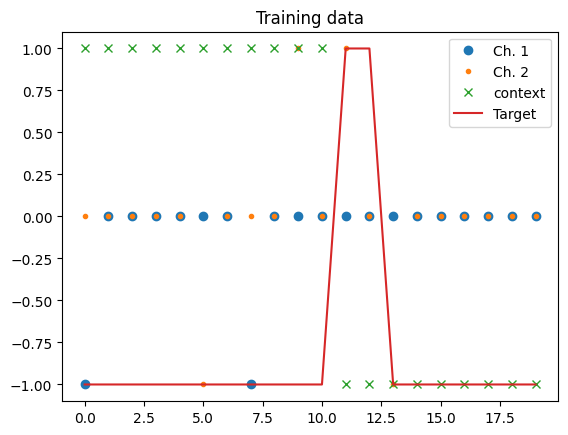

In [ ]:
rr = 0
kk = 90
plt.plot(data_in_train[rr][kk,:,0],'o',label='Ch. 1')
plt.plot(data_in_train[rr][kk,:,1],'.',label='Ch. 2')
plt.plot(data_in_train[rr][kk,:,2],'x',label='context')
plt.plot(data_out_train[rr][kk],label='Target')
plt.legend(loc='upper right')
plt.title('Training data')

#### Model and related hyper-params

In [ ]:
num_layers = 1
input_size = n_channels
hidden_size = N
output_size = 3  # latent state output

In [ ]:
def initialize_weights(N, index_ranges, signs):
    weights = np.zeros((N, N))
    for ii, (start, end) in enumerate(index_ranges):
        limit = 1 / np.sqrt(N) if signs[ii] == 1 else -1/np.sqrt(N)
        weights[:, start:end] = np.random.uniform(0, limit, size=(N, end-start))
    return weights

In [ ]:
def generate_mask(weights, index_ranges, signs):
    mask = np.zeros_like(weights)
    for i, (start, end) in enumerate(index_ranges):
        if signs[i] == 1:
            mask[:, start:end] = np.where(weights[:, start:end] > 0, 1, 0)
        elif signs[i] == -1:
            mask[:, start:end] = np.where(weights[:, start:end] < 0, 1, 0)
    return mask

In [ ]:
# Define the neural network
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, device):

        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=1, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)
        self.output_size = output_size
        self.device = device

    def forward(self, x):
        m = nn.Tanh()
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        nSamp, nSteps, inDim = x.shape

        ops = torch.zeros(nSamp,nSteps,self.hidden_size, requires_grad=False).to(self.device)
        pred = torch.zeros(nSamp,nSteps,self.output_size, requires_grad=False).to(self.device)

        for ii in range(nSteps):
            ip = torch.unsqueeze(x[:,ii,:],1)
            op, ht = self.rnn(ip,h0) ## pass 1 timestep through RNN
            fr_mask = ht.clone()>0
            htt = fr_mask*ht.clone() ## mask firing rate
            h0 = htt ## update hidden state
            ops[:,ii,:] = torch.squeeze(op.clone())

            ## Final prediction at every timestep
            # pred[:,ii,:] = m(self.fc(ops[:, ii, :].clone()))
            pred[:,ii,:] = self.fc(ops[:, ii, :].clone())  # logits (no tanh)

        return pred, htt

In [ ]:
frac_ex = 0.8
frac_in = 1-frac_ex

In [ ]:
signs = [1,-1]
index_ranges = [(0,int(N*frac_ex)),(int(N*frac_ex),N)]

In [ ]:
# Initialize the model
model = {}
weights_init = {}

for cntr in range(nRuns):
    model[cntr] = SimpleRNN(input_size, hidden_size, output_size, device).to(device)
    weights_init[cntr] = initialize_weights(N,index_ranges,signs)
    model[cntr].rnn.weight_hh_l0.data = torch.from_numpy(weights_init[cntr]).float().to(device)

In [ ]:
kk = 0

Text(0, 0.5, 'Counts')

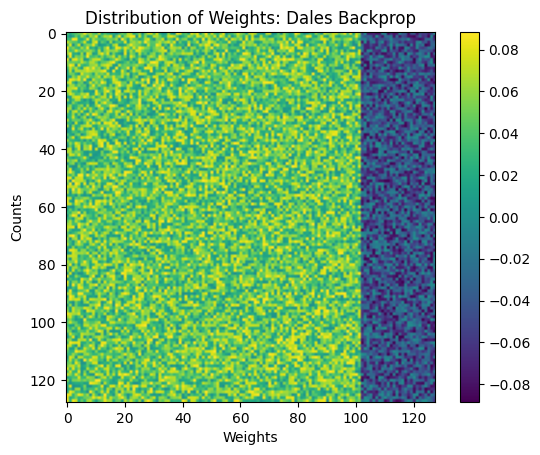

In [ ]:
plt.imshow(weights_init[kk])
plt.colorbar()
plt.title('Initial Weights: Dales Backprop')

plt.hist(weights_init[kk])
plt.title('Distribution of Weights: Dales Backprop')
plt.xlabel('Weights')
plt.ylabel('Counts')

#### Model training

In [ ]:
num_epochs = 200
learning_rate = 0.001

In [ ]:
# criterion = nn.MSELoss()
criterion = nn.CrossEntropyLoss()

optimizer = {}
for cntr in range(nRuns):
    optimizer[cntr] = optim.Adam(model[cntr].parameters(), lr=learning_rate)

In [ ]:
train_losses = np.zeros((nRuns, num_epochs))
test_losses = np.zeros((nRuns, num_epochs))

In [ ]:
# ADD BEFORE the for run in tqdm(range(nRuns)) loop:
checkpoint_epochs = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
save_every_n = 10

In [ ]:
for run in tqdm(range(nRuns)):
    # Add these before training loop
    base_path = '/content/drive/MyDrive/dales-bp-mech-interp/'  # Same as your sys.path
    checkpoint_dir = os.path.join(base_path, f"models/dales_run_{run}/")
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Storage for trajectory analysis
    training_trajectory = {
        'train_losses': [],
        'test_losses': [],
        'weight_snapshots': [],  # For loss landscape
        'gradient_norms': [],    # Track optimization dynamics
        'hidden_states': [],      # Sample hidden states for circuit analysis
        'weight_statistics': [],  # Track E/I weight evolution
    }

    model[run].train()
    train_loss_min = np.inf

    for epoch in range(1, num_epochs+1):
        print('Epoch: ',epoch)

        train_loss = 0.0
        test_loss = 0.0

        # Store gradient norms for this epoch
        epoch_grad_norms = []

        for batch_idx, (inputs, targets) in enumerate(train_loader[run]):
            if train_on_gpu:
                inputs = inputs.float().cuda()
                targets = targets.float().cuda()
                if inputs.dim() == 2:
                    inputs = torch.unsqueeze(inputs, -1)
                if targets.dim() == 2:
                    targets = torch.unsqueeze(targets, -1)
                model[run].cuda()
                model[run].cuda()
            else:
                inputs = inputs.float()
                targets = targets.float()
                if inputs.dim() == 2:
                    inputs = torch.unsqueeze(inputs, -1)
                if targets.dim() == 2:
                    targets = torch.unsqueeze(targets, -1)

            optimizer[run].zero_grad()
            outputs, firing_rates = model[run](inputs)
            if train_on_gpu:
                outputs = outputs.cuda()
            # loss = criterion(outputs, targets)

            # Map targets from {-1,0,+1} to {0,1,2} for CE
            targets_ce = (targets.squeeze(-1) + 1).long()

            # Reshape to (B*T, C) and (B*T)
            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), targets_ce.reshape(-1))

            train_loss += loss.item()

            loss.backward()

            # ADDITION 1: Store gradient norm before step
            total_norm = 0
            for p in model[run].parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2.)
            epoch_grad_norms.append(total_norm)

            optimizer[run].step()

            ## Dale's backprop
            w = model[run].rnn.weight_hh_l0.detach().cpu().numpy()
            mask = generate_mask(w, index_ranges, signs)
            wm = w*mask
            model[run].rnn.weight_hh_l0.data = torch.from_numpy(wm).float().to(device)

            # ADDITION 2: Store sample hidden states for circuit analysis (once per epoch)
            if batch_idx == 0 and (epoch in checkpoint_epochs or epoch % save_every_n == 0):
                with torch.no_grad():
                    # Store a sample of hidden states for later analysis
                    sample_inputs = inputs[:min(10, inputs.size(0))]  # Take first 10 samples
                    _, sample_hidden = model[run](sample_inputs)
                    training_trajectory['hidden_states'].append({
                        'epoch': epoch,
                        'hidden': sample_hidden.detach().cpu().numpy(),
                        'inputs': sample_inputs.detach().cpu().numpy()
                    })

        # ADDITION 3: Compute weight statistics for Dale's analysis
        if epoch % 5 == 0:  # Every 5 epochs
            w_hh = model[run].rnn.weight_hh_l0.detach().cpu().numpy()

            # Create boolean masks for excitatory and inhibitory weights
            exc_mask = np.zeros_like(w_hh, dtype=bool)
            inh_mask = np.zeros_like(w_hh, dtype=bool)

            for i, (start, end) in enumerate(index_ranges):
                if signs[i] == 1:
                    exc_mask[:, start:end] = True
                elif signs[i] == -1:
                    inh_mask[:, start:end] = True

            exc_weights = w_hh[exc_mask]
            inh_weights = w_hh[inh_mask]

            weight_stats = {
                'epoch': epoch,
                'exc_weights_mean': exc_weights.mean() if exc_weights.size > 0 else 0,
                'inh_weights_mean': inh_weights.mean() if inh_weights.size > 0 else 0,
                'exc_weights_std': exc_weights.std() if exc_weights.size > 0 else 0,
                'inh_weights_std': inh_weights.std() if inh_weights.size > 0 else 0,
                'weight_matrix': w_hh.copy()  # Full matrix for detailed analysis
            }
            training_trajectory['weight_statistics'].append(weight_stats)


        if train_loss < train_loss_min:
            print('Epoch: {}, Train Loss Decreased!! ({:.6f}-->{:.6f})'.format(epoch,train_loss_min,train_loss))
            train_loss_min = train_loss

        train_losses[run][epoch-1] = train_loss
        training_trajectory['train_losses'].append(train_loss)
        training_trajectory['gradient_norms'].append(np.mean(epoch_grad_norms))


        # # Test evaluation
        # model[run].eval()  # ADDITION 4: Set to eval mode for testing
        # with torch.no_grad():  # ADDITION 5: No gradients needed for testing
            # for inputs_test, targets_test in test_loader[run]:
                # if train_on_gpu:
        #             inputs_test = inputs_test.float().cuda()
        #             targets_test = targets_test.float().cuda()
        #             if inputs_test.dim() == 2:
        #                 inputs_test = torch.unsqueeze(inputs_test, -1)
        #             if targets_test.dim() == 2:
        #                 targets_test = torch.unsqueeze(targets_test, -1)
        #             model[run].cuda()
        #         else:
        #             inputs_test, targets_test = torch.unsqueeze(inputs_test.float(),-1), torch.unsqueeze(targets_test.float(),-1)

        #         outputs_test, firing_rates_test = model[run](inputs_test)
        #         if train_on_gpu:
        #             outputs_test = outputs_test.cuda()
        #         loss_test = criterion(outputs_test, targets_test)
        #         test_loss += loss_test.item()

        # Test evaluation
        model[run].eval()  # ADDITION 4: Set to eval mode for testing
        with torch.no_grad():  # ADDITION 5: No gradients needed for testing
            for inputs_test, targets_test in test_loader[run]:
                if train_on_gpu:
                    inputs_test = inputs_test.float().cuda()
                    targets_test = targets_test.float().cuda()
                    if inputs_test.dim() == 2:
                        inputs_test = torch.unsqueeze(inputs_test, -1)
                    if targets_test.dim() == 2:
                        targets_test = torch.unsqueeze(targets_test, -1)
                    model[run].cuda()
                else:
                    inputs_test = inputs_test.float()
                    targets_test = targets_test.float()
                    if inputs_test.dim() == 2:
                        inputs_test = torch.unsqueeze(inputs_test, -1)
                    if targets_test.dim() == 2:
                        targets_test = torch.unsqueeze(targets_test, -1)

                outputs_test, firing_rates_test = model[run](inputs_test)
                if train_on_gpu:
                    outputs_test = outputs_test.cuda()

                targets_test_ce = (targets_test.squeeze(-1) + 1).long()
                loss_test = criterion(outputs_test.reshape(-1, outputs_test.shape[-1]), targets_test_ce.reshape(-1))
                test_loss += loss_test.item()

        model[run].train()  # Back to train mode


        test_losses[run][epoch-1] = test_loss
        training_trajectory['test_losses'].append(test_loss)

        print('Epoch: {}, Test Loss({:.6f})'.format(epoch,test_loss))

        # ADDITION 6: Save checkpoints at specified epochs
        if epoch in checkpoint_epochs or epoch % save_every_n == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model[run].state_dict(),
                'optimizer_state_dict': optimizer[run].state_dict(),
                'train_loss': train_loss,
                'test_loss': test_loss,
                'signs': signs,  # Save neuron type assignments
                'index_ranges': index_ranges,  # Save Dale's configuration
            }

            # Save model checkpoint
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pt')
            torch.save(checkpoint, checkpoint_path)

            # Also save just the weights for loss landscape analysis
            weights_path = os.path.join(checkpoint_dir, f'weights_epoch_{epoch}.pt')
            torch.save(model[run].state_dict(), weights_path)

            print(f'Checkpoint saved at epoch {epoch}')


    # ADDITION 7: Save final model and complete trajectory
    final_checkpoint = {
        'epoch': num_epochs,
        'model_state_dict': model[run].state_dict(),
        'optimizer_state_dict': optimizer[run].state_dict(),
        'train_losses': train_losses[run],
        'test_losses': test_losses[run],
        'signs': signs,
        'index_ranges': index_ranges,
        'training_trajectory': training_trajectory
    }

    torch.save(final_checkpoint, os.path.join(checkpoint_dir, 'final_model.pt'))

    # Save trajectory separately for easy loading
    with open(os.path.join(checkpoint_dir, 'training_trajectory.pkl'), 'wb') as f:
        pickle.dump(training_trajectory, f)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  1


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:716: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.rnn_tanh(


Epoch: 1, Train Loss Decreased!! (inf-->11.185950)
Epoch: 1, Test Loss(5.356435)
Checkpoint saved at epoch 1
Epoch:  2
Epoch: 2, Train Loss Decreased!! (11.185950-->10.545779)
Epoch: 2, Test Loss(5.167086)
Epoch:  3
Epoch: 3, Train Loss Decreased!! (10.545779-->10.253567)
Epoch: 3, Test Loss(5.115477)
Epoch:  4
Epoch: 4, Train Loss Decreased!! (10.253567-->10.084860)
Epoch: 4, Test Loss(4.999588)
Epoch:  5
Epoch: 5, Train Loss Decreased!! (10.084860-->9.922357)
Epoch: 5, Test Loss(4.915634)
Checkpoint saved at epoch 5
Epoch:  6
Epoch: 6, Test Loss(5.240360)
Epoch:  7
Epoch: 7, Test Loss(5.019195)
Epoch:  8
Epoch: 8, Train Loss Decreased!! (9.922357-->9.904499)
Epoch: 8, Test Loss(4.919280)
Epoch:  9
Epoch: 9, Train Loss Decreased!! (9.904499-->9.715676)
Epoch: 9, Test Loss(4.817192)
Epoch:  10
Epoch: 10, Train Loss Decreased!! (9.715676-->9.395177)
Epoch: 10, Test Loss(4.493145)
Checkpoint saved at epoch 10
Epoch:  11
Epoch: 11, Train Loss Decreased!! (9.395177-->8.810168)
Epoch: 11, T

 33%|███▎      | 1/3 [01:42<03:24, 102.44s/it]

Epoch: 200, Train Loss Decreased!! (0.322089-->0.316956)
Epoch: 200, Test Loss(0.168932)
Checkpoint saved at epoch 200
Epoch:  1
Epoch: 1, Train Loss Decreased!! (inf-->11.289840)
Epoch: 1, Test Loss(5.353014)
Checkpoint saved at epoch 1
Epoch:  2
Epoch: 2, Train Loss Decreased!! (11.289840-->10.558954)
Epoch: 2, Test Loss(5.135584)
Epoch:  3
Epoch: 3, Train Loss Decreased!! (10.558954-->10.285534)
Epoch: 3, Test Loss(5.095022)
Epoch:  4
Epoch: 4, Train Loss Decreased!! (10.285534-->10.134148)
Epoch: 4, Test Loss(5.014025)
Epoch:  5
Epoch: 5, Train Loss Decreased!! (10.134148-->10.028824)
Epoch: 5, Test Loss(4.957811)
Checkpoint saved at epoch 5
Epoch:  6
Epoch: 6, Train Loss Decreased!! (10.028824-->9.904564)
Epoch: 6, Test Loss(5.165076)
Epoch:  7
Epoch: 7, Test Loss(5.093298)
Epoch:  8
Epoch: 8, Test Loss(4.957744)
Epoch:  9
Epoch: 9, Train Loss Decreased!! (9.904564-->9.903538)
Epoch: 9, Test Loss(4.922567)
Epoch:  10
Epoch: 10, Train Loss Decreased!! (9.903538-->9.754948)
Epoch: 1

 67%|██████▋   | 2/3 [03:25<01:42, 102.55s/it]

Epoch: 200, Train Loss Decreased!! (0.694008-->0.686504)
Epoch: 200, Test Loss(0.345477)
Checkpoint saved at epoch 200
Epoch:  1
Epoch: 1, Train Loss Decreased!! (inf-->11.001181)
Epoch: 1, Test Loss(5.317228)
Checkpoint saved at epoch 1
Epoch:  2
Epoch: 2, Train Loss Decreased!! (11.001181-->10.387087)
Epoch: 2, Test Loss(5.113085)
Epoch:  3
Epoch: 3, Train Loss Decreased!! (10.387087-->10.281552)
Epoch: 3, Test Loss(5.148384)
Epoch:  4
Epoch: 4, Train Loss Decreased!! (10.281552-->10.211154)
Epoch: 4, Test Loss(5.201199)
Epoch:  5
Epoch: 5, Train Loss Decreased!! (10.211154-->10.157922)
Epoch: 5, Test Loss(5.077335)
Checkpoint saved at epoch 5
Epoch:  6
Epoch: 6, Train Loss Decreased!! (10.157922-->10.085790)
Epoch: 6, Test Loss(5.090713)
Epoch:  7
Epoch: 7, Train Loss Decreased!! (10.085790-->9.961957)
Epoch: 7, Test Loss(4.991215)
Epoch:  8
Epoch: 8, Train Loss Decreased!! (9.961957-->9.903514)
Epoch: 8, Test Loss(4.964733)
Epoch:  9
Epoch: 9, Train Loss Decreased!! (9.903514-->9.8

100%|██████████| 3/3 [05:08<00:00, 102.70s/it]

Epoch: 200, Train Loss Decreased!! (0.341288-->0.335257)
Epoch: 200, Test Loss(0.166577)
Checkpoint saved at epoch 200


In [ ]:
# outputs_np = outputs.detach().cpu().numpy()

# For visualization: convert logits to predicted states in {-1,0,+1}
pred_classes = torch.argmax(outputs, dim=-1).float() - 1.0
outputs_np = pred_classes.detach().cpu().numpy()
targets_np = targets.detach().cpu().numpy()
firing_rates_np = firing_rates.detach().cpu().numpy()

# outputs_test_np = outputs_test.detach().cpu().numpy()
pred_classes_test = torch.argmax(outputs_test, dim=-1).float() - 1.0
outputs_test_np = pred_classes_test.detach().cpu().numpy()
targets_test_np = targets_test.detach().cpu().numpy()
firing_rates_test_np = firing_rates_test.detach().cpu().numpy()

Text(0.5, 1.0, 'Test')

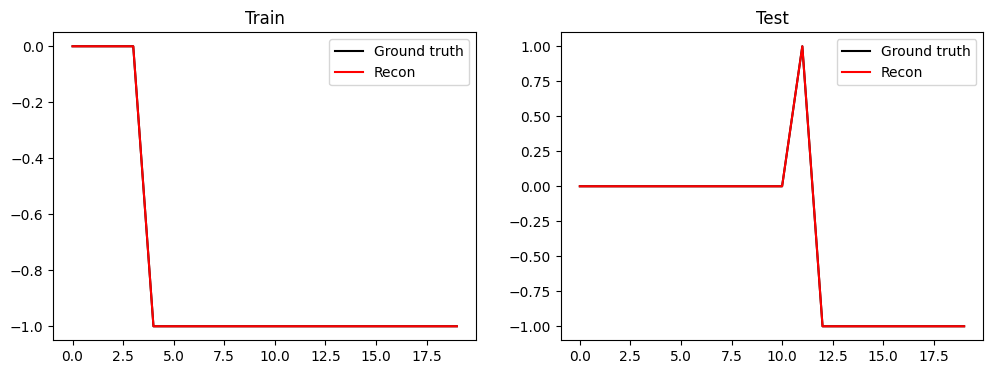

In [ ]:
kk = 10 ## all zeros freaks it out

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.squeeze(targets_np[kk]),label='Ground truth',color='k')
plt.plot(np.squeeze(outputs_np[kk]),label='Recon',color='r')
plt.legend()
plt.title('Train')

plt.subplot(122)
plt.plot(np.squeeze(targets_test_np[kk]),label='Ground truth',color='k')
plt.plot(np.squeeze(outputs_test_np[kk]),label='Recon',color='r')
plt.legend()
plt.title('Test')

In [ ]:
weights_final = {}
for cntr in range(nRuns):
    weights_final[cntr] = model[cntr].rnn.weight_hh_l0.detach().cpu().numpy()

Text(0.5, 1.0, 'Final Weights')

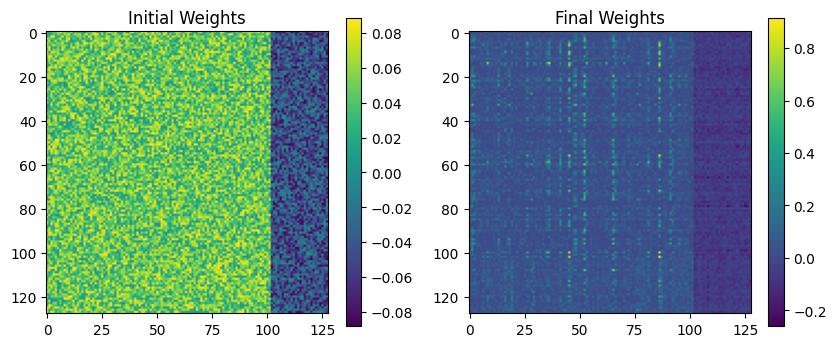

In [ ]:
kk = 0

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(weights_init[kk])
plt.colorbar()
plt.title('Initial Weights')

plt.subplot(122)
plt.imshow(weights_final[kk])
plt.colorbar()
plt.title('Final Weights')

Text(0, 0.5, 'Counts')

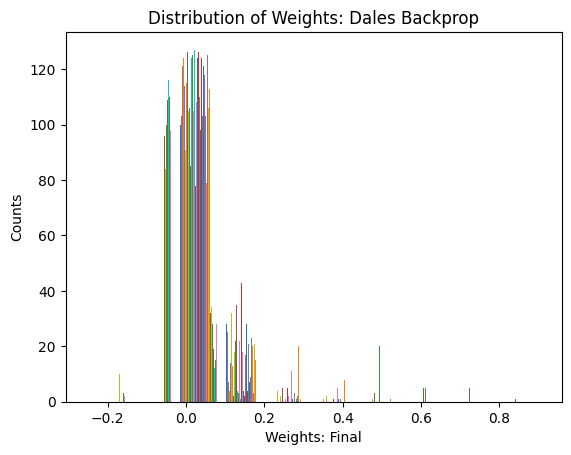

In [ ]:
plt.hist(weights_final[kk])
plt.title('Distribution of Weights: Dales Backprop')
plt.xlabel('Weights: Final')
plt.ylabel('Counts')

In [ ]:
mean_train_losses = np.mean(train_losses, axis=0)
variance_train_losses = np.var(train_losses, axis=0)

mean_test_losses = np.mean(test_losses, axis=0)
variance_test_losses = np.var(test_losses, axis=0)

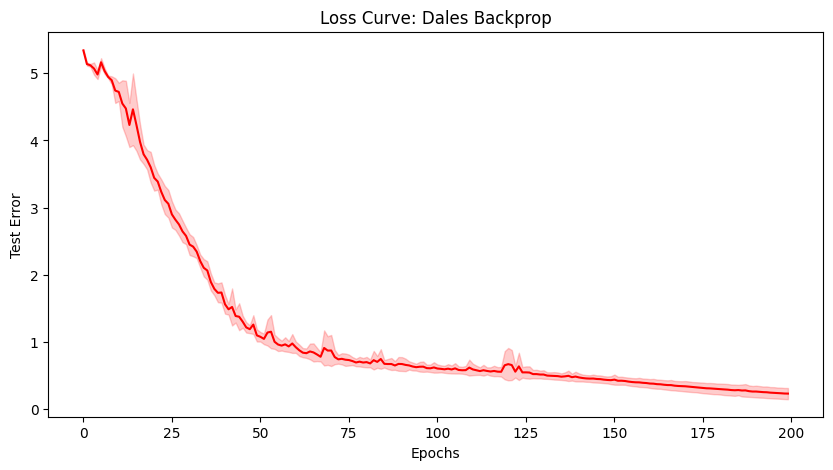

In [ ]:
# Define x-axis (epochs)
x = np.arange(num_epochs)

# Plot shaded error bar using Seaborn
plt.figure(figsize=(10, 5))
# sns.lineplot(x=x, y=mean_train_losses, color='r')
# plt.fill_between(x, mean_train_losses - np.sqrt(variance_train_losses), mean_train_losses + np.sqrt(variance_train_losses),
#                  color='r', alpha=0.2)

sns.lineplot(x=x, y=mean_test_losses, color='r')
plt.fill_between(x, mean_test_losses - np.sqrt(variance_test_losses), mean_test_losses + np.sqrt(variance_test_losses),
                 color='r', alpha=0.2)

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Test Error')
plt.title('Loss Curve: Dales Backprop')

# Show plot
plt.show()

In [ ]:
"""#### Saves"""

save_path = '/content/drive/MyDrive/dales-bp-mech-interp/'
np.save(os.path.join(save_path, 'flipflop_train_losses_dales_backprop'), train_losses)
np.save(os.path.join(save_path, 'flipflop_test_losses_dales_backprop'), test_losses)

# Save dictionary to a Numpy .npz file
np.savez(os.path.join(save_path, 'flipflop_weights_init_dales.npz'), weights_init, pickle=True)
np.savez(os.path.join(save_path, 'flipflop_weights_final_dales.npz'), weights_final, pickle=True)